# <font size=7>8장 모멘텀 전략</font>

### 코드 8-1 AAPL에 대한 주가와 모멘텀 그래프1

[*********************100%%**********************]  1 of 1 completed


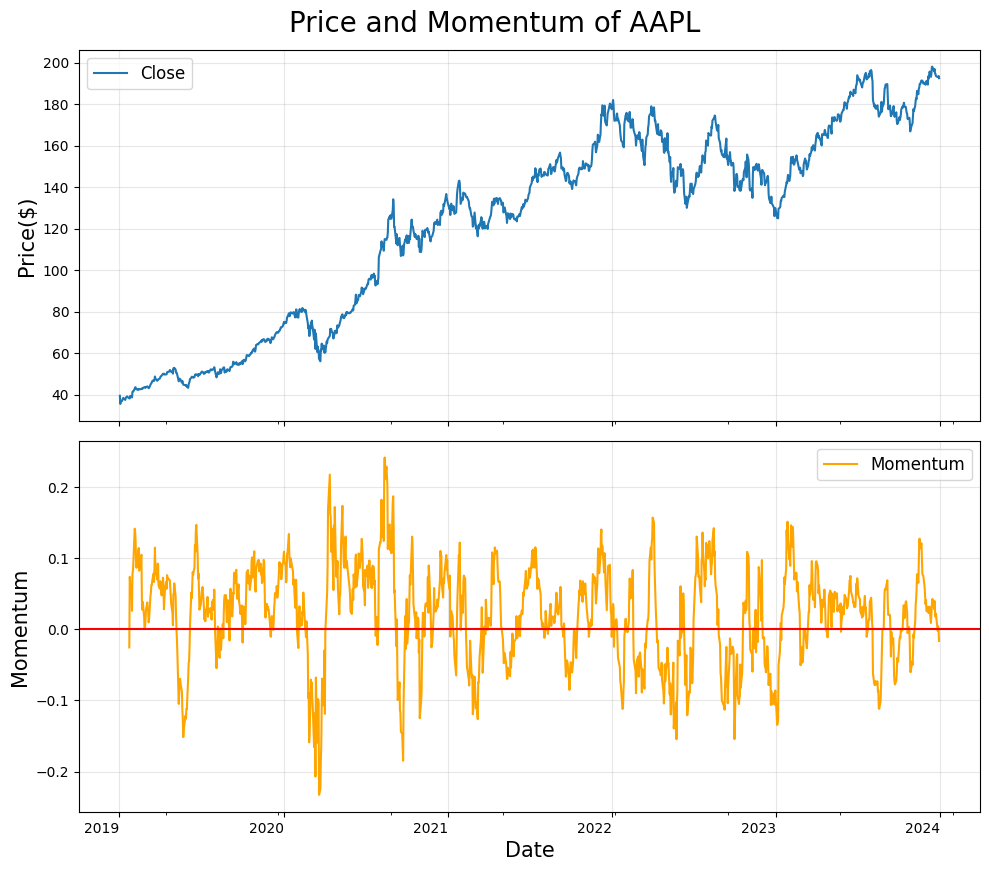

In [1]:
# 필요한 모듈 가져오기
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

# 주가 데이터 다운로드
ticker = "AAPL"
start_date = "2019-01-01"
end_date = "2024-01-01"
df = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

# 모멘텀 지표 계산
data = df.copy()
period = 14
data['Mom'] = data['Close'].pct_change(periods=period)

# 그래프 그리기
fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

start = '2019-01-01'
end = '2024-01-01'

data['Close'].loc[start:end].plot(ax=ax[0], label='Close')
ax[0].set_ylabel('Price($)',fontsize=15)
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=12, loc='best')

data['Mom'].loc[start:end].plot(ax=ax[1], label='Momentum', color='orange')
ax[1].axhline(y=0, color='red', linestyle='-')
ax[1].set_xlabel('Date', fontsize=15)
ax[1].set_ylabel('Momentum',fontsize=15)
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=12, loc='best')

plt.suptitle(f'Price and Momentum of {ticker}', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### 코드 8-2 AAPL에 대한 주가와 모멘텀 그래프2

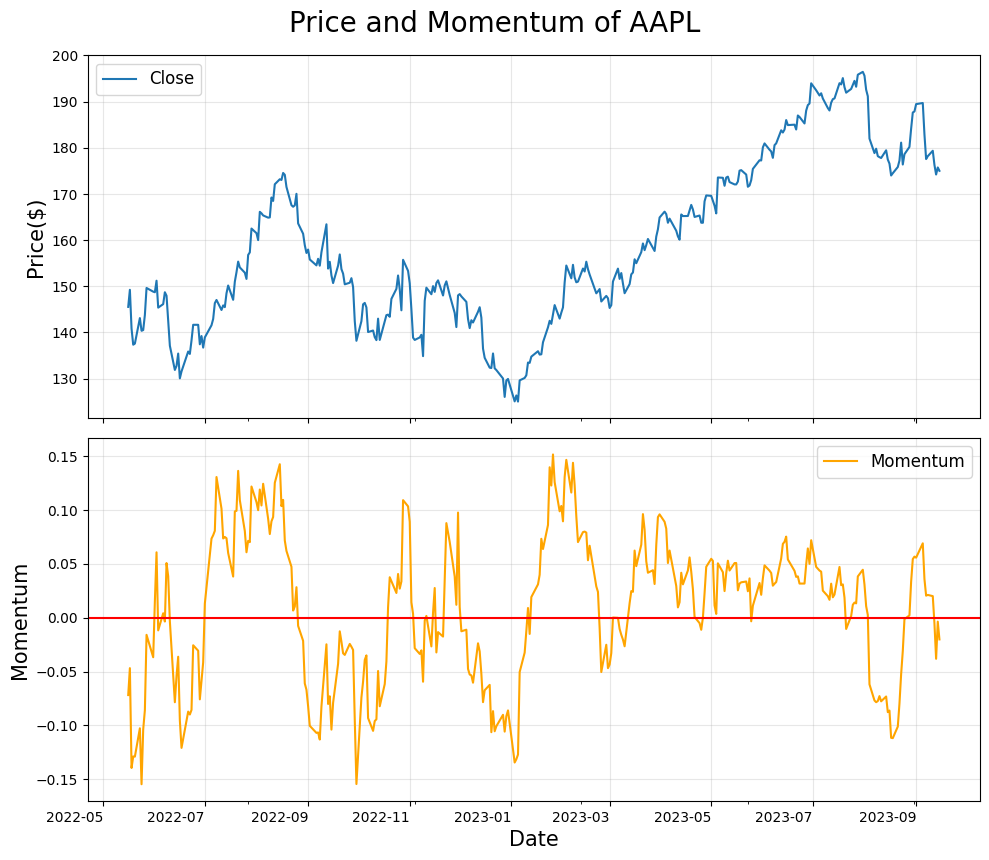

In [2]:
fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

start = '2022-05-15'
end = '2023-09-15'

data['Close'].loc[start:end].plot(ax=ax[0], label='Close')
ax[0].set_ylabel('Price($)',fontsize=15)
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=12)

data['Mom'].loc[start:end].plot(ax=ax[1], label='Momentum', color='orange')
ax[1].axhline(y=0, color='red', linestyle='-')
ax[1].set_xlabel('Date', fontsize=15)
ax[1].set_ylabel('Momentum',fontsize=15)
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=12)

plt.suptitle(f'Price and Momentum of {ticker}', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=0)
# plt.savefig('mom_02.png', dpi=300)
plt.show()

### 코드 8-3 MOM Strategy1 백테스트 함수

In [3]:
def mom_strategy1(df, p, sl, verbose=True):
    fee_rate = 0.001
    data = df.copy()
    period = p
    stop_loss = sl
    
    data['Mom'] = data['Close'].pct_change(periods=period)
    data.dropna(inplace=True)

    mom_pos = pd.Series(np.where(data['Mom']>0, 1, 0), \
                        index=data.index)
    mom_signals = mom_pos.diff().fillna(0)

    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash

    prices = data['Close'].values
    signals = mom_signals.values
    positions = np.zeros(len(data))
    pos = 0    
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 1: # 모멘텀 양전 -> 매수
                pos = 1
                positions[i] = 1
                entry_price = prices[i]
                num = int(cash/(entry_price*(1+fee_rate)))
                cash -= entry_price*num*(1+fee_rate)
                stop_loss_price = entry_price*(1 - stop_loss)
        elif pos == 1:
            if prices[i] < stop_loss_price: # 손절 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)  
            else: # 손절가 갱신
                positions[i] = 1
                stop_loss_price =\
                max(stop_loss_price, prices[i]*(1 - stop_loss))

        # asset 갱신
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*num    

    data['Position'] = positions
    data['Signal'] = data['Position'].diff().fillna(0)
    
    data['Buy_Price'] = \
    np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = \
    np.where(data['Signal'] == -1, data['Close'], np.nan)   
    
    data['Cumulative_Return'] = asset/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    if verbose:
        print(f'Final cumulative return of the strategy: '
          f'{100*final_cum_return:.2f}%')
    return data, final_cum_return

In [4]:
def tear_sheet1(data):
    fee_rate = 0.001
    
    # 투자기간 Trading Period in Years
    trading_period = len(data)/252 # in year
    print(f'Trading Period:{trading_period:.1f} years')    
    
    # 수익률 Rate of Return
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate)) - 1
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    print(f'Final cumulative return of the strategy:'
    f'{100*final_cum_return:.2f}%, Buy&Hold:{100*buy_and_hold:.2f}%')
    
    # 연평균 성장률 CAGR   
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold+1)**(1/trading_period)-1
    print(f'Strategy CAGR:{100*CAGR_strategy:.2f}%, '
           f'Benchmark CAGR:{100*CAGR_benchmark:.2f}%')
    
    # 샤프 지수 Sharpe Ratio
    risk_free_rate = 0.003
    strategy_daily_return = data['Cumulative_Return'].pct_change().fillna(0)
    mean_return = strategy_daily_return.mean()*252
    std_return = strategy_daily_return.std()*np.sqrt(252)
    sharpe_ratio = (mean_return - risk_free_rate) / std_return
    print(f'Sharpe Ratio: {sharpe_ratio:.2f}')
    
    # 최대 낙폭 Maximum Drawdown
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    max_drawdown = data['Drawdown'].min()
    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min() 
    print(f'Strategy MDD: {100*max_drawdown:.2f}%, '
          f'Benchmark MDD: {100*mdd_benchmark:.2f}%')   

    # 승률 Win Rate
    buy_signals = data[data['Signal'] == 1].index
    sell_signals = data[data['Signal'] == -1].index
    returns = []
    holding_periods = []
    for buy_date in buy_signals:
        sell_dates = sell_signals[sell_signals > buy_date]
        if not sell_dates.empty:
            sell_date = sell_dates[0]
            buy_price = data.loc[buy_date, 'Close']
            sell_price = data.loc[sell_date, 'Close']
            return_pct = sell_price*(1-fee_rate)/(buy_price*(1+fee_rate)) - 1
            returns.append(return_pct)          
            holding_period = np.busday_count(buy_date.date(), sell_date.date())
            holding_periods.append(holding_period)
    profitable_trades = len([r for r in returns if r > 0])
    loss_trades = len([r for r in returns if r <= 0])
    total_trades = len(returns)
    win_rate = profitable_trades / total_trades if total_trades > 0 else 0
    print(f'Number of Profitable Trades:{profitable_trades}, '
    f'Number of Loss Trades:{loss_trades}, Win Rate:{100*win_rate:.2f}%')
    
    # 평균 보유 기간 Average Holding Period
    if holding_periods:
        average_holding_period = np.mean(holding_periods)
    else:
        average_holding_period = 0
    print(f'Average Holding Period:{average_holding_period:.1f}days')


    # 평균 이익과 손실 계산 Calculation of Average Profit and Loss
    if profitable_trades > 0:
        average_profit = np.mean([r for r in returns if r > 0])
    else:
        average_profit = 0
    
    if loss_trades > 0:
        average_loss = np.mean([r for r in returns if r <= 0])
    else:
        average_loss = 0
    print(f'Avg ROR/trade in profitable trades:{average_profit:.3f}%, '
          f'Avg ROR/trade in loss trades:{average_loss:.3f}%')
    
    # 이익 손실 비율 계산 Calculation of Profit/Loss Ratio
    if average_loss != 0:
        profit_loss_ratio = average_profit / abs(average_loss)
    else:
        profit_loss_ratio = np.inf  # If there are no losses, the ratio is infinitely large.
    
    print(f'Profit/Loss Ratio: {profit_loss_ratio:.2f}')

### 코드 8-4 MOM Strategy1 파라미터 최적화

In [5]:
def mom_parameter_optimizer1(input_df):
    period = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,\
              16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
    stop_loss = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,\
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2] 
    ret_list = []  

    for x1, x2, in [(a,b) for a in period for b in stop_loss]:
        df = input_df.copy()
        data, ror = mom_strategy1(df, x1, x2, verbose=False)
        ret_list.append((x1, x2, ror))

    max_ror = max(ret_list, key=lambda x:x[2])[2]
    max_tups = [tup for tup in ret_list if tup[2] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    opt_param1 = int(np.median(params1))
    opt_param2 = round(np.median(params2),4)

    optimal_df = pd.DataFrame(ret_list, \
                columns=['period','stop_loss','ror'])
    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:{opt_param1, opt_param2}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2), optimal_df

ticker = 'AAPL'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

opt_params, opt_df = mom_parameter_optimizer1(df)

data, ret = mom_strategy1(df, opt_params[0], opt_params[1])
tear_sheet1(data)

[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(12, 0.07, np.float64(3.9807983698158367))]
Optimal Parameters:(12, np.float64(0.07)), Optimized Return:398.08%
Final cumulative return of the strategy: 398.08%
Trading Period:4.9 years
Final cumulative return of the strategy:398.08%, Buy&Hold:390.10%
Strategy CAGR:38.37%, Benchmark CAGR:37.91%
Sharpe Ratio: 1.46
Strategy MDD: -32.87%, Benchmark MDD: -31.43%
Number of Profitable Trades:10, Number of Loss Trades:10, Win Rate:50.00%
Average Holding Period:47.5days
Avg ROR/trade in profitable trades:0.249%, Avg ROR/trade in loss trades:-0.051%
Profit/Loss Ratio: 4.92


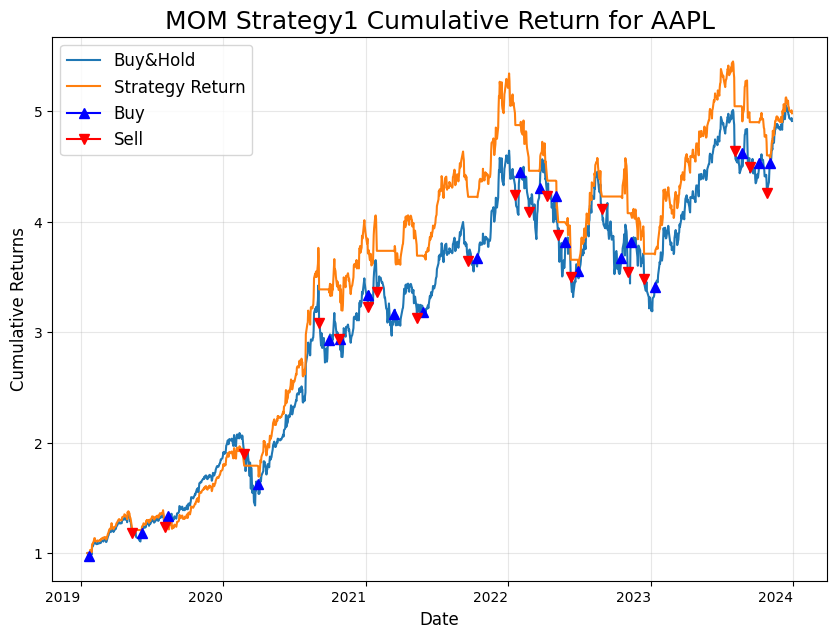

In [6]:
buy_and_hold = data['Close']/data['Close'].iloc[0]
buy_price = data['Buy_Price']/data['Close'].iloc[0]
sell_price = data['Sell_Price']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data['Cumulative_Return'].plot(ax=ax, label='Strategy Return')
buy_price.plot(ax=ax, label='Buy', marker='^', color='b', markersize=7)
sell_price.plot(ax=ax, label='Sell', marker='v', color='r', markersize=7)

ax.set_title(f'MOM Strategy1 Cumulative Return for {ticker}', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

### 코드 8-5 AAPL에 대한 주가와 MFI 그래프

[*********************100%%**********************]  1 of 1 completed


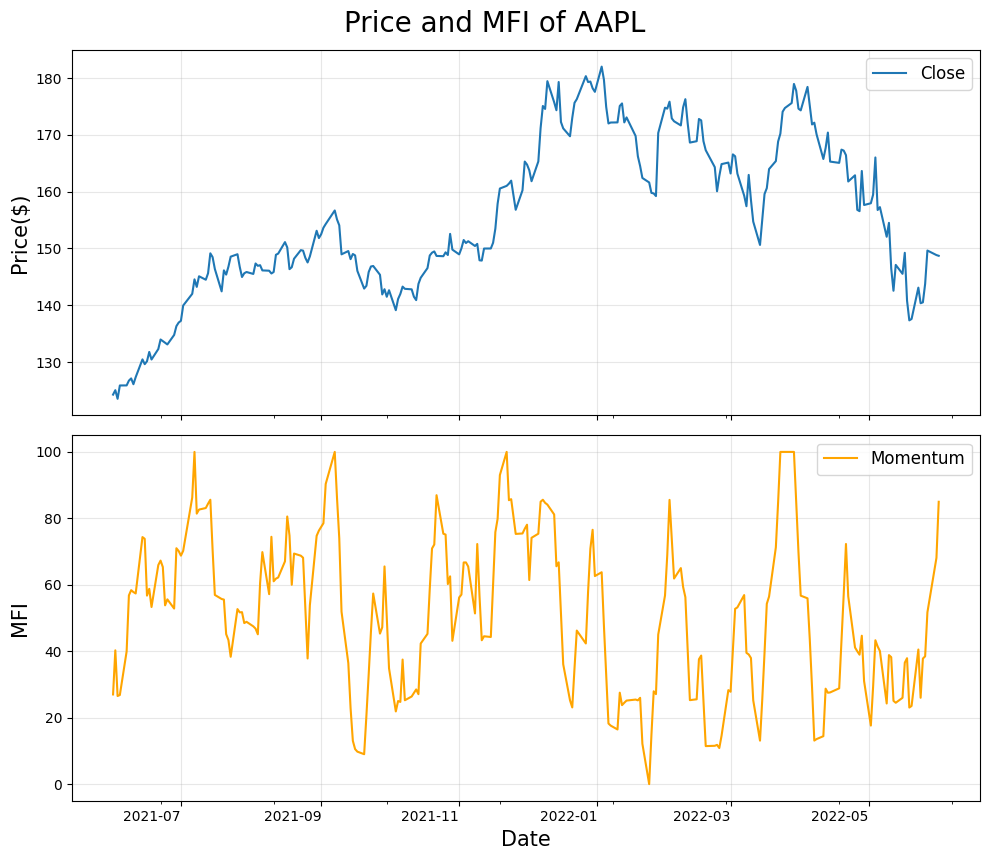

In [7]:
# 필요한 모듈 가져오기
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

# 주가 데이터 다운로드
ticker = "AAPL"
start_date = "2019-01-01"
end_date = "2024-01-01"
df = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

# MFI지표 계산
data = df.copy()
period = 7
data['MFI'] = \
ta.volume.money_flow_index(data.High,data.Low,data.Close,data.Volume,period)

# 그래프 그리기
fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

start = '2021-06-01'
end = '2022-06-01'

data['Close'].loc[start:end].plot(ax=ax[0], label='Close')
ax[0].set_ylabel('Price($)',fontsize=15)
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=12, loc='upper right')

data['MFI'].loc[start:end].plot(ax=ax[1], label='Momentum', color='orange')
ax[1].set_xlabel('Date', fontsize=15)
ax[1].set_ylabel('MFI',fontsize=15)
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=12, loc='upper right')

plt.suptitle(f'Price and MFI of {ticker}', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=0)
# plt.savefig('mom_05.png', dpi=300)
plt.show()

In [8]:
ticker = 'AAPL'
start_date = '2018-12-01'
# start_date = '2024-01-01'
end_date = '2024-01-01'
# end_date = '2024-06-30'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

df['MFI'] = ta.volume.money_flow_index(df.High,df.Low,df.Close,df.Volume,7)

df = df.loc['2019-01-01':].copy()

[*********************100%%**********************]  1 of 1 completed


In [9]:
data, ror = mom_strategy1(df, 12, 0.07)

Final cumulative return of the strategy: 398.08%


### 그림 8-6 MOM Strategy1 백테스트 결과와 MFI 시각화

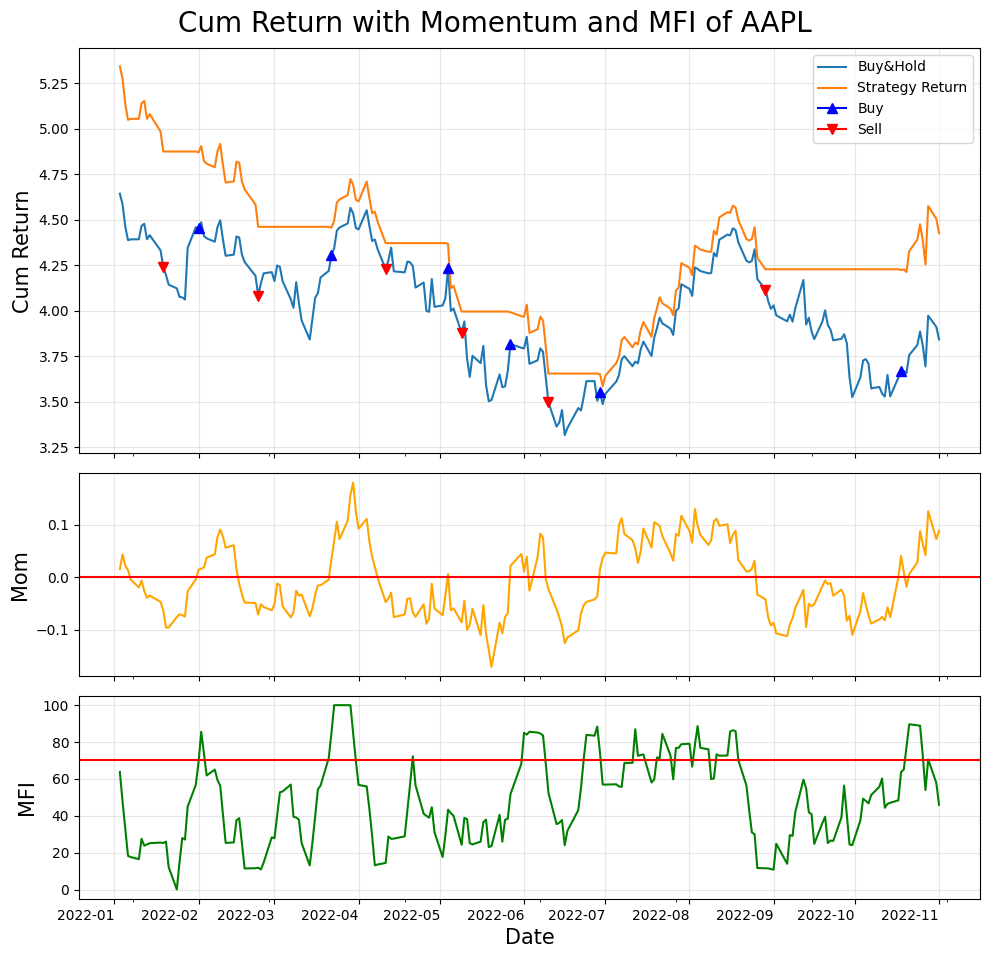

In [10]:
buy_and_hold = data['Close']/data['Close'].iloc[0]
buy_price = data['Buy_Price']/data['Close'].iloc[0]
sell_price = data['Sell_Price']/data['Close'].iloc[0]

fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True, height_ratios=(5,2.5,2.5))

start = '2022-01-01'
end = '2022-11-01'

buy_and_hold.loc[start:end].plot(ax=ax[0], label='Buy&Hold')
data['Cumulative_Return'].loc[start:end].plot(ax=ax[0], label='Strategy Return')
buy_price.loc[start:end].plot(ax=ax[0], label='Buy', marker='^', color='b', markersize=7)
sell_price.loc[start:end].plot(ax=ax[0], label='Sell', marker='v', color='r', markersize=7)
ax[0].set_ylabel('Cum Return',fontsize=15)
ax[0].grid(alpha=0.3)
ax[0].legend()

data['Mom'].loc[start:end].plot(ax=ax[1], label='Momentum', color='orange')
ax[1].axhline(y=0, color='red', linestyle='-')
ax[1].set_ylabel('Mom',fontsize=15)
ax[1].grid(alpha=0.3)

data['MFI'].loc[start:end].plot(ax=ax[2], label='MFI', color='green')
ax[2].axhline(y=70, color='red', linestyle='-')
ax[2].set_xlabel('Date', fontsize=15)
ax[2].set_ylabel('MFI',fontsize=15)
ax[2].grid(alpha=0.3)

plt.suptitle(f'Cum Return with Momentum and MFI of {ticker}', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig('mom_06.png', dpi=300)
plt.show()

### 코드 8-6 MOM Strategy2의 백테스트 함수

In [11]:
def mom_strategy2(df, p1, p2, ml, sl, verbose=True):
    fee_rate = 0.001
    data = df.copy()

    period1 = p1
    period2 = p2
    mfi_level = ml
    stop_loss = sl
    
    data['Mom'] = data['Close'].pct_change(periods=period1)
    data['MFI'] = ta.volume.money_flow_index(data.High, \
                data.Low, data.Close, data.Volume, period2) 
    data.dropna(inplace=True)

    mom_pos = pd.Series(np.where(data['Mom']>0, 1, 0), \
                        index=data.index)
    mom_signals = mom_pos.diff().fillna(0)

    cash_init = 10000
    cash = cash_init
    asset = np.zeros(len(data))
    asset[0] = cash

    prices = data['Close'].values
    signals = mom_signals.values
    mfi = data['MFI'].values
    positions = np.zeros(len(data))
    pos = 0    
    
    for i in range(1, len(data)):
        if pos == 0:
            if signals[i] == 1 and mfi[i] > mfi_level: # 매수
                pos = 1
                positions[i] = 1
                entry_price = prices[i]
                num = int(cash/(entry_price*(1+fee_rate)))
                cash -= entry_price*num*(1+fee_rate)
                stop_loss_price = entry_price*(1 - stop_loss)
        elif pos == 1:
            if prices[i] < stop_loss_price: # 손절 발생
                pos = 0
                cash += prices[i]*num*(1-fee_rate)  
            else: # 손절가 갱신
                positions[i] = 1
                stop_loss_price =\
                max(stop_loss_price, prices[i]*(1 - stop_loss))

        # asset 갱신
        if pos == 0:
            asset[i] = cash
        elif pos == 1:
            asset[i] = cash + prices[i]*num    

    data['Position'] = positions
    data['Signal'] = data['Position'].diff().fillna(0)
    
    data['Buy_Price'] = \
    np.where(data['Signal'] == 1, data['Close'], np.nan)
    data['Sell_Price'] = \
    np.where(data['Signal'] == -1, data['Close'], np.nan)   
    
    data['Cumulative_Return'] = asset/cash_init
    final_cum_return = data['Cumulative_Return'].iloc[-1] - 1
    if verbose:
        print(f'Final cumulative return of the strategy: '
          f'{100*final_cum_return:.2f}%')
    return data, final_cum_return

### 코드 8-7 MOM Strategy2의 파라미터 최적화

In [12]:
def mom_parameter_optimizer2(input_df):
    period1 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    period2 = [3, 4, 5, 6, 7, 8, 9, 10]
    mfi_level = [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,\
                 56, 57, 58]
    stop_loss = [0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12,\
                 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]  
    ret_list = []  

    for x1, x2, x3, x4 in [(a,b,c,d) for a in period1 for b in \
                period2 for c in mfi_level for d in stop_loss]:
        df = input_df.copy()
        data, ror = mom_strategy2(df, x1, x2, x3, x4, verbose=False)
        ret_list.append((x1, x2, x3, x4, ror))

    max_ror = max(ret_list, key=lambda x:x[4])[4]
    max_tups = [tup for tup in ret_list if tup[4] == max_ror]
    params1 = [tup[0] for tup in max_tups]
    params2 = [tup[1] for tup in max_tups]
    params3 = [tup[2] for tup in max_tups]
    params4 = [tup[3] for tup in max_tups]    
    opt_param1 = int(np.median(params1))
    opt_param2 = int(np.median(params2))
    opt_param3 = round(np.median(params3),1)
    opt_param4 = round(np.median(params4),4)    

    optimal_df = pd.DataFrame(ret_list, columns=
                ['period1','period2', 'mfi_level', 'stop_loss','ror'])
    print(f'Max Tuples:{max_tups}')
    print(f'Optimal Parameters:'
    f'{opt_param1, opt_param2, opt_param3, opt_param4}, '
    f'Optimized Return:{100*max_ror:.2f}%')

    return (opt_param1, opt_param2, opt_param3, opt_param4), optimal_df

ticker = 'AAPL'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

import time
t1 = time.time()

opt_params, optimal_df = mom_parameter_optimizer2(df)

t2 = time.time()
print(f'Elapsed Time:{(t2-t1)/60:.2f}min')

data, ret = mom_strategy2(df, opt_params[0], opt_params[1], \
                          opt_params[2], opt_params[3])
tear_sheet1(data)

[*********************100%%**********************]  1 of 1 completed


Max Tuples:[(9, 4, 46, 0.06, np.float64(4.469685269595347)), (9, 4, 47, 0.06, np.float64(4.469685269595347))]
Optimal Parameters:(9, 4, np.float64(46.5), np.float64(0.06)), Optimized Return:446.97%
Elapsed Time:24.61min
Final cumulative return of the strategy: 446.97%
Trading Period:5.0 years
Final cumulative return of the strategy:446.97%, Buy&Hold:402.11%
Strategy CAGR:40.89%, Benchmark CAGR:38.48%
Sharpe Ratio: 1.60
Strategy MDD: -22.75%, Benchmark MDD: -31.43%
Number of Profitable Trades:15, Number of Loss Trades:8, Win Rate:65.22%
Average Holding Period:38.7days
Avg ROR/trade in profitable trades:0.158%, Avg ROR/trade in loss trades:-0.051%
Profit/Loss Ratio: 3.10


In [13]:
# ticker = 'AAPL'
ticker = 'TSLA'
start_date = '2019-01-01'
end_date = '2024-01-01'
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=False)

[*********************100%%**********************]  1 of 1 completed


In [14]:
# AAPL: 12, 0.07
# TSLA: 18, 0.13
# data1, ror = mom_strategy1(df, 12, 0.07)
data1, ror = mom_strategy1(df, 18, 0.13)

Final cumulative return of the strategy: 2216.43%


In [15]:
# AAPL: 9, 4, 46, 0.06
# TSLA: 6, 9, 57, 0.1
# data, ror = mom_strategy2(df, 9, 4, 46, 0.06)
data, ror = mom_strategy2(df, 6, 9, 57, 0.1)

Final cumulative return of the strategy: 4822.54%


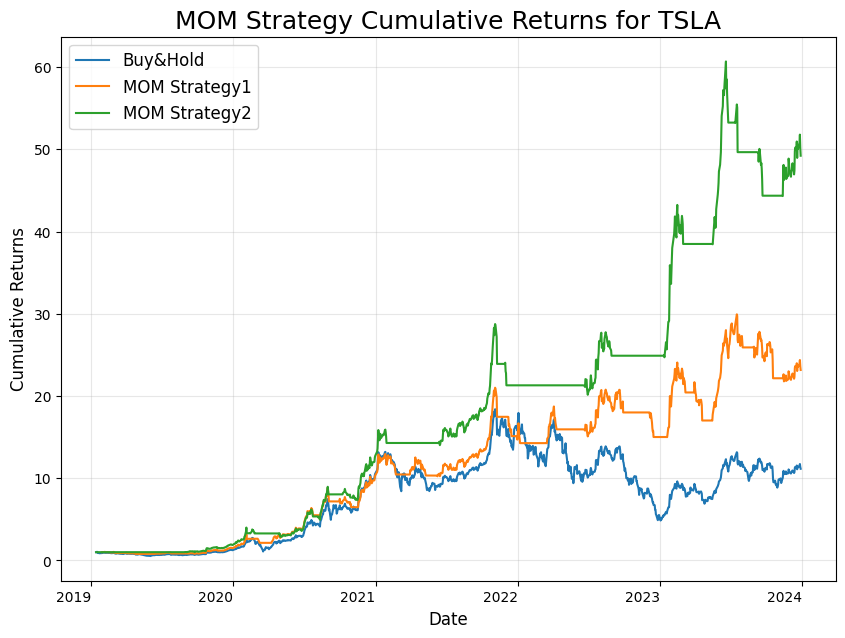

In [16]:
buy_and_hold = data['Close']/data['Close'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

buy_and_hold.plot(ax=ax, label='Buy&Hold')
data1['Cumulative_Return'].plot(ax=ax, label='MOM Strategy1')
data['Cumulative_Return'].plot(ax=ax, label='MOM Strategy2')

ax.set_title(f'MOM Strategy Cumulative Returns for {ticker}', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.show()

## **8.3.3 전략 검증**

In [17]:
from datetime import datetime
def rolling_test2(ticker, date):
    # 전체 데이터 다운로드
    middle_date = date
    middle_date_dt = datetime.strptime(middle_date, '%Y-%m-%d')
    
    start_date_dt = middle_date_dt.replace(year=middle_date_dt.year - 5)
    start_date = start_date_dt.strftime('%Y-%m-%d')   
    
    end_date_dt = middle_date_dt.replace(year=middle_date_dt.year + 2)
    end_date = end_date_dt.strftime('%Y-%m-%d')
    
    df = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

    # 파라미터 최적화와 백테스트
    df_train = df.loc[:middle_date].copy()
    opt_params, optimal_df = mom_parameter_optimizer2(df_train)   
    
    df_test = df.loc[middle_date:].copy()
    data, ret = mom_strategy2(df_test, opt_params[0], opt_params[1], opt_params[2], opt_params[3])

    # 연평균 성장률 CAGR
    fee_rate = 0.001
    trading_period = len(data)/252 # in years   
    buy_and_hold = data['Close'].iloc[-1]*(1-fee_rate)\
    /(data['Close'].iloc[0]*(1+fee_rate))
    CAGR_strategy = (data['Cumulative_Return'].iloc[-1])**(1/trading_period)-1
    CAGR_benchmark = (buy_and_hold)**(1/trading_period)-1

    # 최대 낙폭 Maximum Drawdown
    data['Cumulative_Max'] = data['Cumulative_Return'].cummax()
    data['Drawdown'] = data['Cumulative_Return'] / data['Cumulative_Max'] - 1
    mdd_strategy = data['Drawdown'].min()

    cumulative_returns = (1 + data['Close'].pct_change()).cumprod()
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns/running_max - 1
    mdd_benchmark = drawdown.min()  

    return CAGR_strategy, mdd_strategy, CAGR_benchmark, mdd_benchmark

In [19]:
### This will take really long!!! Maybe more than a few hours on Windows.
dates = ['2018-01-01','2018-07-01','2019-01-01','2019-07-01','2020-01-01',\
         '2020-07-01','2021-01-01','2021-07-01','2022-01-01','2022-07-01']
results = \
{('Strategy','CAGR'):[],('Strategy','MDD'):[],('Benchmark','CAGR'):[],\
           ('Benchmark','MDD'):[]}
ticker = 'AAPL'

for date in dates:
    CAGR_strategy, mdd_strategy, CAGR_benchmark, mdd_benchmark = \
    rolling_test2(ticker, date)
    results[('Strategy','CAGR')].append(CAGR_strategy)
    results[('Strategy','MDD')].append(mdd_strategy)
    results[('Benchmark','CAGR')].append(CAGR_benchmark)
    results[('Benchmark','MDD')].append(mdd_benchmark)
    print(f'Date:{date}, CAGR_Strategy:{100*CAGR_strategy:.2f}%, '
          f'MDD_Strategy:{100*mdd_strategy:.2f}% CAGR_Benchmark:'
        f'{100*CAGR_benchmark:.2f}%, MDD_Benchmark:{100*mdd_benchmark:.2f}%')
results_df = pd.DataFrame(results, index=dates)
results_df

[*********************100%%**********************]  1 of 1 completed


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
values1 = results_df[('Strategy','CAGR')].values
values2 = results_df[('Benchmark','CAGR')].values
values3 = results_df[('Strategy','MDD')].values
values4 = results_df[('Benchmark','MDD')].values

# Define the position of bars on x-axis
bar_width = 0.3
index = np.arange(len(dates))

# Create figure and axes with figsize
fig, ax = plt.subplots(2,1, figsize=(12, 10), sharex=True)

# Create grouped bar graph
ax[0].bar(index, values1*100, bar_width, label='CAGR_Strategy')
ax[0].bar(index + bar_width, values2*100, bar_width, label='CAGR_Benchmark')

ax[1].bar(index, values3*100, bar_width, label='MDD_Strategy')
ax[1].bar(index + bar_width, values4*100, bar_width, label='MDD_Benchmark')

# Add labels, title, and ticks
ax[0].set_ylabel('CAGR(%)', fontsize=15)
ax[0].set_title(f'MOM Strategy1 Rolling CAGR and MDD for {ticker}', fontsize=20)

ax[1].set_ylabel('MDD(%)', fontsize=15)
ax[1].set_xlabel('Dates', fontsize=15)
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(dates)
ax[0].legend(fontsize=13)
ax[1].legend(fontsize=13)
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()